Next, run the following cells to set up the Kaggle environment and download the dataset. You might need to install `kaggle` first if it's not already installed.

In [ ]:
from google.colab import userdata
import os

# Install kaggle if not already installed
!pip install kaggle

# Create .kaggle directory if it doesn't exist
!mkdir -p ~/.kaggle

# Retrieve Kaggle credentials from Colab's secrets
KAGGLE_USERNAME = userdata.get('KAGGLE_USERNAME')
KAGGLE_KEY = userdata.get('KAGGLE_KEY')

# Check if credentials are retrieved
if not KAGGLE_USERNAME or not KAGGLE_KEY:
    raise ValueError("Kaggle username or key not found in Colab secrets. Please set them as 'KAGGLE_USERNAME' and 'KAGGLE_KEY' in the secrets panel.")

# Create kaggle.json file
kaggle_json_content = f'{{"username":"{KAGGLE_USERNAME}","key":"{KAGGLE_KEY}"}}'
with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
    f.write(kaggle_json_content)

# Set correct permissions
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API key setup complete.")

Kaggle API key setup complete.


Now you can download the CIFAKE dataset using the Kaggle API command:

In [ ]:
!kaggle datasets download -d birdy654/cifake-real-and-ai-generated-synthetic-images
!unzip cifake-real-and-ai-generated-synthetic-images.zip -d cifake_dataset

Streaming output truncated to the last 5000 lines.
  inflating: cifake_dataset/train/REAL/4500 (10).jpg  
  inflating: cifake_dataset/train/REAL/4500 (2).jpg  
  inflating: cifake_dataset/train/REAL/4500 (3).jpg  
  inflating: cifake_dataset/train/REAL/4500 (4).jpg  
  inflating: cifake_dataset/train/REAL/4500 (5).jpg  
  inflating: cifake_dataset/train/REAL/4500 (6).jpg  
  inflating: cifake_dataset/train/REAL/4500 (7).jpg  
  inflating: cifake_dataset/train/REAL/4500 (8).jpg  
  inflating: cifake_dataset/train/REAL/4500 (9).jpg  
  inflating: cifake_dataset/train/REAL/4500.jpg  
  inflating: cifake_dataset/train/REAL/4501 (10).jpg  
  inflating: cifake_dataset/train/REAL/4501 (2).jpg  
  inflating: cifake_dataset/train/REAL/4501 (3).jpg  
  inflating: cifake_dataset/train/REAL/4501 (4).jpg  
  inflating: cifake_dataset/train/REAL/4501 (5).jpg  
  inflating: cifake_dataset/train/REAL/4501 (6).jpg  
  inflating: cifake_dataset/train/REAL/4501 (7).jpg  
  inflating: cifake_dataset/train

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications

# 1. Load the CIFAKE dataset (available on Kaggle)
# For this code, we assume you have the data in 'train' and 'test' folders
IMG_SIZE = (128, 128) # Improvement: Higher resolution than 32x32
BATCH_SIZE = 32

# 2. IMPROVEMENT: Using ResNet50 (Transfer Learning) instead of simple CNN
base_model = applications.ResNet50(input_shape=(128, 128, 3),
                                  include_top=False,
                                  weights='imagenet')
base_model.trainable = False # Freeze the pre-trained weights

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2), # Improvement: Adding dropout for better generalization
    layers.Dense(1, activation='sigmoid') # Binary output: Real or Fake
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# To run this, you'll need to link your Kaggle API to Colab to download 'birdy654/cifake-real-and-ai-generated-synthetic-images'
print("Model Ready for Training")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Model Ready for Training


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Preprocessing: ResNet50 expects specific normalization
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    horizontal_flip=True # Data augmentation to make the model more robust
)

train_generator = train_datagen.flow_from_directory(
    '/content/cifake_dataset/train', # This is the folder name from the zip
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    '/content/cifake_dataset/train',
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 80000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.


In [ ]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

Epoch 1/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 117s 42ms/step - accuracy: 0.7241 - loss: 0.5433 - val_accuracy: 0.7885 - val_loss: 0.4711
Epoch 2/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 101s 40ms/step - accuracy: 0.7750 - loss: 0.4763 - val_accuracy: 0.7980 - val_loss: 0.4440
Epoch 3/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 100s 40ms/step - accuracy: 0.7875 - loss: 0.4537 - val_accuracy: 0.7989 - val_loss: 0.4315
Epoch 4/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 101s 40ms/step - accuracy: 0.7912 - loss: 0.4480 - val_accuracy: 0.8054 - val_loss: 0.4256
Epoch 5/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 101s 41ms/step - accuracy: 0.7943 - loss: 0.4435 - val_accuracy: 0.7791 - val_loss: 0.4629
Epoch 6/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 102s 41ms/step - accuracy: 0.7980 - loss: 0.4378 - val_accuracy: 0.8112 - val_loss: 0.4157
Epoch 7/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 102s 41ms/step - accuracy: 0.7976 - loss: 0.4390 - val_accuracy: 0.8142 - val_loss: 0.4206
Epoch 8/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 101s 41ms/step - accuracy: 

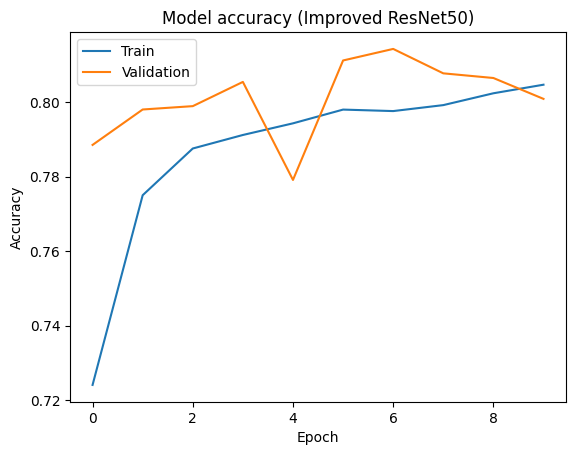

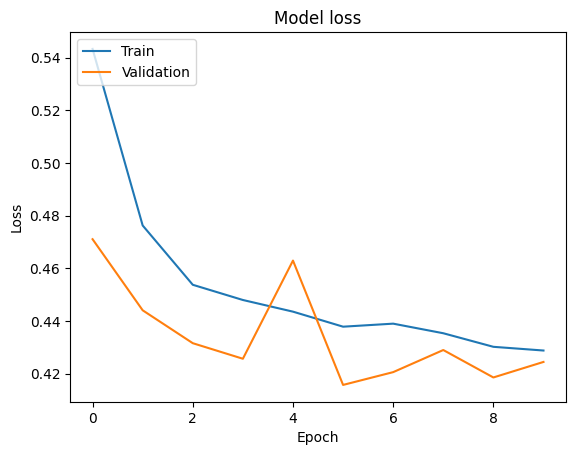

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy (Improved ResNet50)')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
# 1. Unfreeze the base model layers
base_model.trainable = True

# 2. Refreeze everything except the last 30 layers
# (This allows the model to learn complex textures)
for layer in base_model.layers[:-30]:
    layer.trainable = False

# 3. Use a VERY LOW learning rate
# This ensures we don't 'break' the pre-trained knowledge
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 4. Train for 10 more epochs
history_fine = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

Epoch 1/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 200s 72ms/step - accuracy: 0.8138 - loss: 0.7296 - val_accuracy: 0.8571 - val_loss: 0.3528
Epoch 2/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 158s 63ms/step - accuracy: 0.8479 - loss: 0.3549 - val_accuracy: 0.8372 - val_loss: 0.3528
Epoch 3/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 202s 63ms/step - accuracy: 0.8593 - loss: 0.3324 - val_accuracy: 0.8787 - val_loss: 0.2880
Epoch 4/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 159s 63ms/step - accuracy: 0.8654 - loss: 0.3190 - val_accuracy: 0.8371 - val_loss: 0.3744
Epoch 5/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 159s 64ms/step - accuracy: 0.8724 - loss: 0.3042 - val_accuracy: 0.8546 - val_loss: 0.3252
Epoch 6/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 159s 64ms/step - accuracy: 0.8774 - loss: 0.2914 - val_accuracy: 0.8749 - val_loss: 0.2978
Epoch 7/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 159s 64ms/step - accuracy: 0.8824 - loss: 0.2824 - val_accuracy: 0.8829 - val_loss: 0.2756
Epoch 8/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 159s 64ms/step - accuracy: 

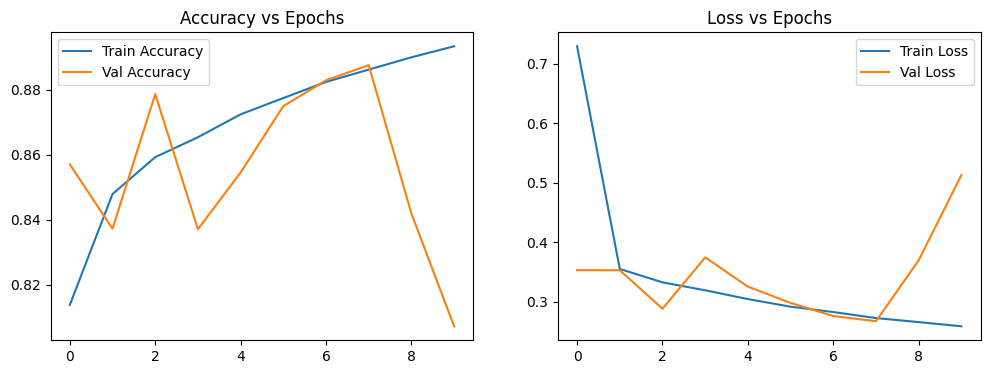

625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 32ms/step


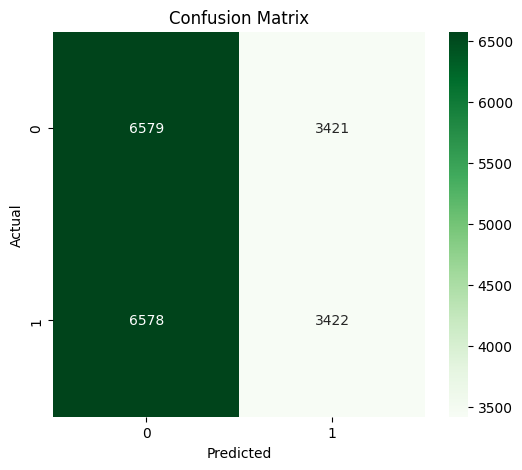

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# 1. Plot the Training History
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_fine.history['accuracy'], label='Train Accuracy')
plt.plot(history_fine.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy vs Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_fine.history['loss'], label='Train Loss')
plt.plot(history_fine.history['val_loss'], label='Val Loss')
plt.title('Loss vs Epochs')
plt.legend()
plt.show()

# 2. Confusion Matrix
validation_generator.reset()
Y_pred = model.predict(validation_generator)
y_pred = (Y_pred > 0.5).astype(int).flatten()
y_true = validation_generator.classes

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()